In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

***APPLE CASE***

In [ ]:
tickers = "AAPL"
aapl = yf.Ticker(tickers)
data = aapl.history(start="2024-01-01", end="2025-01-01", interval="1d")
print(data.head())

                                 Open        High         Low       Close  \
Date                                                                        
2024-01-02 00:00:00-05:00  185.225793  186.502538  181.999316  183.731323   
2024-01-03 00:00:00-05:00  182.325916  183.968852  181.544030  182.355606   
2024-01-04 00:00:00-05:00  180.277196  181.207533  179.020264  180.039673   
2024-01-05 00:00:00-05:00  180.118854  180.880926  178.317559  179.317169   
2024-01-08 00:00:00-05:00  180.217791  183.691712  179.633861  183.652115   

                             Volume  Dividends  Stock Splits  
Date                                                          
2024-01-02 00:00:00-05:00  82488700        0.0           0.0  
2024-01-03 00:00:00-05:00  58414500        0.0           0.0  
2024-01-04 00:00:00-05:00  71983600        0.0           0.0  
2024-01-05 00:00:00-05:00  62379700        0.0           0.0  
2024-01-08 00:00:00-05:00  59144500        0.0           0.0  


In [ ]:
close_prices = data['Close']
df_close = pd.DataFrame({"Date": close_prices.index, "Close": close_prices.values})
df_close.reset_index(drop=True, inplace=True)
print(df_close.head())

                       Date       Close
0 2024-01-02 00:00:00-05:00  183.731323
1 2024-01-03 00:00:00-05:00  182.355606
2 2024-01-04 00:00:00-05:00  180.039673
3 2024-01-05 00:00:00-05:00  179.317169
4 2024-01-08 00:00:00-05:00  183.652115


In [ ]:
df_close.to_csv("/tmp/aapl_close_prices.csv", index=False)


In [ ]:
df_apple = pd.read_csv("/tmp/aapl_close_prices.csv")
df_apple.head()

,Date,Close
0,2024-01-02 00:00:00-05:00,183.731323
1,2024-01-03 00:00:00-05:00,182.355606
2,2024-01-04 00:00:00-05:00,180.039673
3,2024-01-05 00:00:00-05:00,179.317169
4,2024-01-08 00:00:00-05:00,183.652115


/var/folders/62/rh9l84sx6d70_dkrpcr4kfbr0000gn/T/ipykernel_39106/729823453.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df_apple['Date'] = pd.to_datetime(df_apple['Date'])


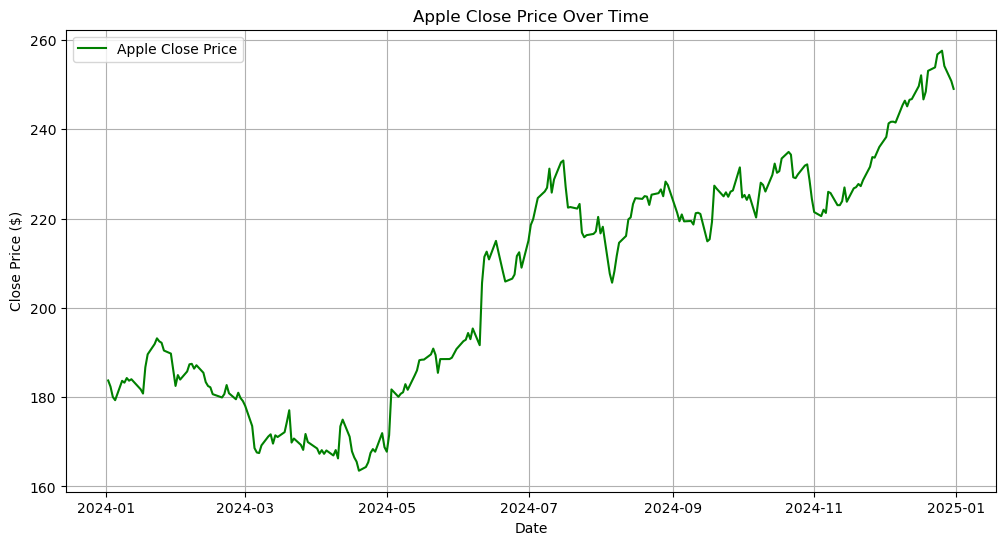

In [ ]:
df_apple['Date'] = pd.to_datetime(df_apple['Date'])
df_apple.set_index('Date', inplace=True)
plt.figure(figsize=(12, 6))
plt.plot(df_apple.index, df_apple['Close'], color ='green', label='Apple Close Price')
plt.title('Apple Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.grid(True)
plt.legend()
plt.show()

***DATA COMPLETETENESS***

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2024-01-02 00:00:00-05:00 to 2024-12-31 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          252 non-null    float64
 1   High          252 non-null    float64
 2   Low           252 non-null    float64
 3   Close         252 non-null    float64
 4   Volume        252 non-null    int64  
 5   Dividends     252 non-null    float64
 6   Stock Splits  252 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.8 KB


In [ ]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02,252.000000,252.0
mean,205.394750,207.338035,203.672086,205.646688,5.710678e+07,0.003929,0.0
std,25.405580,25.654099,25.206496,25.575701,3.072330e+07,0.031000,0.0
min,163.858751,164.899254,162.600186,163.511887,2.323470e+07,0.000000,0.0
25%,181.995386,183.594911,180.695792,182.455799,4.174738e+07,0.000000,0.0
50%,212.665250,215.300387,210.318397,212.620598,4.983090e+07,0.000000,0.0
75%,225.997005,227.868149,223.909162,225.913483,6.279472e+07,0.000000,0.0
max,256.787255,258.686881,256.230300,257.612732,3.186799e+08,0.250000,0.0


In [ ]:
data.shape

(252, 7)

In [ ]:
data.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [ ]:
print(f"The missing values in the dataset: {data['Close'].isnull().sum()}")

The missing values in the dataset: 0


In [ ]:
total_rows = len(data)

missing_info = pd.DataFrame({
    'missing_count': data.isnull().sum(),
    'missing_percentage': (data.isnull().sum() / total_rows) * 100
})

print(missing_info)


              missing_count  missing_percentage
Open                      0                 0.0
High                      0                 0.0
Low                       0                 0.0
Close                     0                 0.0
Volume                    0                 0.0
Dividends                 0                 0.0
Stock Splits              0                 0.0


***DATA LATENCY***

In [ ]:
min_close = data['Close'].min()
max_close = data['Close'].max()
print(f"Minimum Close Price: {min_close}")
print(f"Maximum Close Price: {max_close}")
print(f"Difference between Max and Min Close Price: {max_close - min_close}")

Minimum Close Price: 163.5118865966797
Maximum Close Price: 257.61273193359375
Difference between Max and Min Close Price: 94.10084533691406


***DATA CONSISTENCY***

In [ ]:
print(data.dtypes)

Open            float64
High            float64
Low             float64
Close           float64
Volume            int64
Dividends       float64
Stock Splits    float64
dtype: object


In [ ]:
print(data.apply(lambda x: x.map(type).nunique()))

Open            1
High            1
Low             1
Close           1
Volume          1
Dividends       1
Stock Splits    1
dtype: int64


***ERROR RATE***

In [ ]:
missing_rate = data.isnull().mean() * 100
print(missing_rate)

In [ ]:
duplicate_rate = data.duplicated().mean() * 100
print(duplicate_rate)

In [ ]:
Q1 = data['Close'].quantile(0.25)
Q3 = data['Close'].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data['Close'] < Q1 - 1.5 * IQR) | (data['Close'] > Q3 + 1.5 * IQR)).mean() * 100
print(outliers)

0.0


***DATA ACCURACY***

In [ ]:
minimum_price = data['Close'].min()
max_price = data['Close'].max()

print("The minimum recorded price is", minimum_price)

print("The maximum recorded price is", max_price)

The minimum recorded price is 163.5118865966797
The maximum recorded price is 257.61273193359375


In [ ]:
negative_price_count = (data['Close'] < 0).sum()
print("Number of records with negative Close price:", negative_price_count)

Number of records with negative Close price: 0


In [ ]:
valid_close = data['Close'] > 0
valid_volume = data['Volume'] > 0
valid_dividends = data['Dividends'].notnull()

accurate_records = data[valid_close & valid_volume & valid_dividends]
data_accuracy_rate = (len(accurate_records) / len(data)) * 100
print(f"✅ Data Accuracy Rate: {data_accuracy_rate:.2f}%")

✅ Data Accuracy Rate: 100.00%


In [ ]:
invalid_records = data[~(valid_close & valid_volume & valid_dividends)]
invalid_value_rate = (len(invalid_records) / len(data)) * 100
print(f"❌ Invalid Value Rate: {invalid_value_rate:.2f}%")


❌ Invalid Value Rate: 0.00%


In [ ]:
duplicate_rows = data.duplicated()
duplicate_accuracy_rate = ((~duplicate_rows).sum() / len(data)) * 100
print(f"📄 Duplicate Accuracy Rate: {duplicate_accuracy_rate:.2f}%")

📄 Duplicate Accuracy Rate: 100.00%


In [ ]:
unit_price_accuracy = (data['Close'] > 0).sum() / len(data) * 100
print(f"💰 Close Price Field Accuracy Rate: {unit_price_accuracy:.2f}%")

💰 Close Price Field Accuracy Rate: 100.00%
